In [1]:
# import wandb
import rdkit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl

# from pytorch_lightning.callbacks import RichProgressBar
# from pytorch_lightning.loggers import WandbLogger

from torchinfo import summary
from smiles_utils import *

torch.set_default_dtype(torch.float32)

In [2]:
class Delimited:
    def __init__(self):
        pass

    def __call__(self, line):
        smiles = line[0]
        smiles_sol = line[1]
        prop = np.array(line[2:])
        return smiles, smiles_sol,prop

class MolGraphDataset(Dataset):
    def __init__(self, file_path, set_name, transform=None):
        self.data = pd.read_csv(file_path+set_name+'.csv')
        self.file_path = file_path
        self.conditional = Delimited()
        
    
    def __len__(self):
        return len(self.data)
    
    def _convertToAdj(self,smiles_list):
        adj = [Chem.rdmolops.GetAdjacencyMatrix(Chem.MolFromSmiles(i),useBO=True)\
               +np.eye(len(Chem.MolFromSmiles(i).GetAtoms()))\
               if i !='gas' else np.zeros([2,2]) for i in smiles_list]
        
        max_atom_nums = np.max([i_adj.shape[0] for i_adj in adj])
        
        adj = np.concatenate([np.pad(i_adj,((0,max_atom_nums-i_adj.shape[0]),
                                            (0,max_atom_nums-i_adj.shape[0])),
                                     'constant',
                                     constant_values=0).reshape(1,
                                                                max_atom_nums,
                                                                max_atom_nums) for i_adj in adj],
                             axis=0)
        
        return adj, max_atom_nums
    
    def _convertToFeatures(self,smiles_list,max_atom_nums):
        features = [np.concatenate([np.concatenate([atom_symbol_HNums(atom),
                                                    atom_degree(atom),
                                                    atom_Aroma(atom),
                                                    atom_Hybrid(atom),
                                                    atom_ring(atom),
                                                    atom_FC(atom)],
                                                   axis=0).reshape(1,-1)\
                                    for atom in Chem.MolFromSmiles(i).GetAtoms()],axis=0)\
                    if i !='gas' else np.zeros([2,45]) for i in smiles_list]
        
        features = np.concatenate([np.pad(i_features,
                                          ((0,max_atom_nums-i_features.shape[0]),
                                           (0,0)),
                                          'constant',
                                          constant_values=0).reshape(1,
                                                                     max_atom_nums,
                                                                     -1)\
                                   for i_features in features],axis=0)
        
        EZ_features = [EZ_stereo(smiles) if smiles !='gas'\
                       else np.zeros([2,2]) for smiles in smiles_list]
        
        EZ_features = np.concatenate([np.pad(i_EZ_features,
                                             ((0,max_atom_nums-i_EZ_features.shape[0]),(0,0)),
                                             'constant', constant_values=0).reshape(1,max_atom_nums,-1)\
                                      for i_EZ_features in EZ_features],axis=0)
        
        features = np.concatenate([features,EZ_features],axis=2)
        
        return features
    
    def _make_matrix(self,smiles_list):
        adj, max_atom_nums = self._convertToAdj(smiles_list)
        features = self._convertToFeatures(smiles_list,max_atom_nums)
        
        return features, adj
        
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        batch = np.array(self.data.iloc[idx]).reshape(1,-1)
        smiles_list, smiles_sol_list,prop = list(),list(),list()
        for record_i in batch:
            smiles_i,smiles_sol_i,prop_i = self.conditional(record_i)
            smiles_list.append(smiles_i)
            smiles_sol_list.append(smiles_sol_i)
            prop.append(prop_i)
            
        chrom_X,chrom_A = self._make_matrix(smiles_list)
        X_A = np.concatenate([chrom_X,chrom_A],axis=2)
        
        sol_X,sol_A = self._make_matrix(smiles_sol_list)
        X_A_sol = np.concatenate([sol_X,sol_A],axis=2)
        
        prop = pd.DataFrame(prop)
        sample = {'input':[X_A,X_A_sol],'output':np.array(prop).astype('float32')}
        return sample
    
def collate_max_atoms(samples):
    max_numatom = np.max([i["input"][0].shape[1] for i in samples])
    max_numatom_sol = np.max([i["input"][1].shape[1] for i in samples])
    padding_num = [max_numatom-i["input"][0].shape[1] for i in samples]
    padding_num_sol = [max_numatom_sol-i["input"][1].shape[1] for i in samples]
    padded_samples = [nn.functional.pad(torch.from_numpy(i["input"][0]),(0,num,0,num),value=0) for i,num in zip(samples, padding_num)]
    padded_samples_sol = [nn.functional.pad(torch.from_numpy(i["input"][1]),(0,num,0,num),value=0) for i,num in zip(samples, padding_num_sol)]
    output = np.stack([i["output"] for i in samples],axis=0)
    
    return ([torch.stack(padded_samples).squeeze().type(torch.float32).contiguous(), 
             torch.stack(padded_samples_sol).squeeze().type(torch.float32).contiguous()], 
            torch.from_numpy(output.squeeze()).type(torch.float32).contiguous())

In [3]:
class GCN(nn.Module):
    def __init__(self, unit, input_shape, activation=nn.ReLU(), is_bias=False):
        super(GCN, self).__init__()
        self.hidden_dim = unit
        self.input_shape = input_shape
        self.activation= activation
        
        self.Linear = nn.Linear(input_shape, self.hidden_dim, bias=is_bias)
        
        if unit != input_shape:
            self.Linear_dim = nn.Linear(input_shape, self.hidden_dim, bias=is_bias)
            nn.init.xavier_uniform_(self.Linear_dim.weight)
            
        nn.init.xavier_uniform_(self.Linear.weight)
        
    def forward(self, X, A):
        
        mat = torch.matmul(A, self.Linear(X))
        output = self.activation(mat)
        
        if self.hidden_dim == self.input_shape:
            output += X
        else:
            output += self.Linear_dim(X)
            
        return  output

In [4]:
class GCNNet(pl.LightningModule):
    def __init__(self, file_path, pred_dim=9):
        super().__init__()
        self.file_path = file_path
        self.pred_dim = pred_dim
        self.depth = 6
        self.dims = [47,]+[128,]*self.depth
        activation = nn.LeakyReLU(0.1)
        self.loss_fn = self.mae_loss
        is_bias = False
        
        self.GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        self.sol_GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        
        self.linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(1024),
                                        nn.Linear(1024, 512, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(512)])
        self.sol_linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(1024),
                                            nn.Linear(1024, 512, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(512),])
        
        self.pred_list = nn.ModuleList([nn.Linear(1024, 512, bias=True),
                                      nn.LeakyReLU(0.1),
                                      nn.BatchNorm1d(512),
                                        nn.Linear(512, 256, bias=True),
                                      nn.LeakyReLU(0.1),
                                      nn.BatchNorm1d(256),
                                        nn.Linear(256, 128, bias=True),
                                      nn.LeakyReLU(0.1),
                                      nn.BatchNorm1d(128),
                                      nn.Dropout(0.5),
                                      nn.Linear(128, pred_dim, bias=True)])
        
        self.linear_list.apply(self._init_weights)
        self.sol_linear_list.apply(self._init_weights)
        self.pred_list.apply(self._init_weights)
        self.train_preds = []
        self.train_props = []
        self.val_preds = []
        self.val_props = []
        self.train_error = []
        self.val_error = []
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0)
    def forward(self, X_A, X_A_sol):
        
        X, A = X_A[:,:,:47], X_A[:,:,47:]
        X_sol, A_sol =  X_A_sol[:,:,:47], X_A_sol[:,:,47:]
        
        H = X
        H_sol = X_sol
        
        for GCN, sol_GCN in zip(self.GCN_list, self.sol_GCN_list):
            H = GCN(H, A)
            H_sol = sol_GCN(H_sol, A_sol)
            
        H = torch.sum(H, dim=-2)
        H_sol = torch.sum(H_sol, dim=-2)
        
        for layer, sol_layer in zip(self.linear_list, self.sol_linear_list):
            H = layer(H)
            H_sol = sol_layer(H_sol)
        output = torch.cat([H,H_sol], dim=-1)
        
        for layer in self.pred_list:
            output = layer(output)
            
        return output
    
    def configure_optimizers(self):
        learning_rate = 1e-3
        wd = 5e-4
        lr_decay = 1-0.015
        lr_patience = 50
        self.optimizer = torch.optim.Adam(self.parameters(), lr = learning_rate, weight_decay = wd,)# eps=1e-7,  amsgrad=False)
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_patience, gamma=lr_decay)
        sch_config = {
            "scheduler" : scheduler,
            "interval" : "epoch",
        }
        return [self.optimizer], [sch_config]
    
    def mae_loss(self, y, y_hat):
        y = y.reshape(-1, self.pred_dim)
        return torch.mean(torch.absolute((y[~torch.isnan(y)]-y_hat[~torch.isnan(y)])))
    
    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss
    
    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss    

In [5]:
# Build 한 GCNNet Architecture 의 모든 learnable 한 파라미터(W,b) 개수를 확인해보기!

model_test = GCNNet("data/")

from prettytable import PrettyTable

def count_parameters(model_test):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model_test.named_parameters():
        if not parameter.requires_grad: continue
        param = parameter.numel()
        table.add_row([name, param])
        total_params+=param
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params

count_parameters(model_test)

+----------------------------------+------------+
|             Modules              | Parameters |
+----------------------------------+------------+
|     GCN_list.0.Linear.weight     |    6016    |
|   GCN_list.0.Linear_dim.weight   |    6016    |
|     GCN_list.1.Linear.weight     |   16384    |
|     GCN_list.2.Linear.weight     |   16384    |
|     GCN_list.3.Linear.weight     |   16384    |
|     GCN_list.4.Linear.weight     |   16384    |
|     GCN_list.5.Linear.weight     |   16384    |
|   sol_GCN_list.0.Linear.weight   |    6016    |
| sol_GCN_list.0.Linear_dim.weight |    6016    |
|   sol_GCN_list.1.Linear.weight   |   16384    |
|   sol_GCN_list.2.Linear.weight   |   16384    |
|   sol_GCN_list.3.Linear.weight   |   16384    |
|   sol_GCN_list.4.Linear.weight   |   16384    |
|   sol_GCN_list.5.Linear.weight   |   16384    |
|       linear_list.0.weight       |   131072   |
|        linear_list.0.bias        |    1024    |
|       linear_list.2.weight       |    1024    |


2199817

### GCNNet에 Train 된 Weight 적용하기

In [6]:
db_path = 'data/' # train 된 weight 가 저장된 위치

model_trained = GCNNet.load_from_checkpoint(checkpoint_path=db_path + '/last_For_All_AdachDB_GCN_TL.ckpt', # GCNNet에 weight 적용!
    file_path=db_path + '/last_For_All_AdachDB_GCN_TL.ckpt')

In [7]:
model_trained # 잘 적용 되었다!

GCNNet(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_st

### 새로운 GCNNet_transfer Model building 하기

In [8]:
# 사전 훈련된 Model 의 parameter 들은 고정시키기!

for param in model_trained.parameters():
    param.requires_grad = False

In [9]:
# 교체할 레이어를 새로 정의

model_trained.pred_dim = 336

new_layers = [nn.Linear(512, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.5),
              nn.Linear(1024, 2048, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.4),
              nn.Linear(2048, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.2),
              nn.Linear(1024, model_trained.pred_dim, bias=True)]


# 원래의 pred_list 중에서 교체하고 싶은 마지막 3개의 레이어를 바꿈
# 원래의 pred_list를 가져오되, 앞의 3 layer 는 그대로 유지하고, 나머지를 교체할 레이어로 변경

model_trained.pred_list = nn.ModuleList(list(model_trained.pred_list[:3]) + new_layers)
model_trained

GCNNet(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [10]:
# 새롭게 교체한, 마지막 pred_list 의 Grad 켜줌! 

for param in list(model_trained.pred_list[3:]):
    param.requires_grad = True 

In [11]:
# 열려있는 Layer 확인!

for name, param in model_trained.named_parameters(): # resnet18 model 의 parameter 에 접근하여, 이름과 값을 가져옴
    
    if param.requires_grad == True: # 그 중에서, requires_grad=True 가 켜져있는 것?
        
        print(name) # 그 이름과, 파라미터! : 마지막 한 layer 만 켜져있음!

pred_list.3.weight
pred_list.3.bias
pred_list.6.weight
pred_list.6.bias
pred_list.9.weight
pred_list.9.bias
pred_list.12.weight
pred_list.12.bias


In [12]:
count_parameters(model_trained)

+---------------------+------------+
|       Modules       | Parameters |
+---------------------+------------+
|  pred_list.3.weight |   524288   |
|   pred_list.3.bias  |    1024    |
|  pred_list.6.weight |  2097152   |
|   pred_list.6.bias  |    2048    |
|  pred_list.9.weight |  2097152   |
|   pred_list.9.bias  |    1024    |
| pred_list.12.weight |   344064   |
|  pred_list.12.bias  |    336     |
+---------------------+------------+
Total Trainable Params: 5067088


5067088

### 새로운 GCNNet_transfer Model 학습하기

In [13]:
### 2. DataLoader 를 통한 : train, val. Data 준비 ###

db_path = 'data/' # train 된 model 이 저장된 위치

train_set = MolGraphDataset(db_path,"Train_abs_spectrum_sum_12496_251216")
train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Test_abs_spectrum_sum_12496_251216")
val_loader = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

In [14]:
len(train_set) + len(val_set)

12496

In [15]:
from pytorch_lightning.loggers import CSVLogger

model_name = 'Trasfer_learning_base'
model_path = 'model/'+model_name


csv_logger = CSVLogger(save_dir=db_path+model_path+"/logs/", name=model_name)

checkpoint_callback = pl.callbacks.ModelCheckpoint(dirpath=db_path+model_path, 
                                                   filename='{epoch}-{train_loss:.4f}-{val_loss:.4f}',
                                                   every_n_epochs=100,
                                                   save_top_k=10,
                                                   monitor='val_loss',
                                                   mode='min',
                                                   save_last=True)

lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="epoch")

In [ ]:
### trainer Module : pl.Trainer() 로 정의하여, epoch 부분을 파격적으로 간결화


trainer = pl.Trainer(max_epochs=4000, accelerator='gpu', devices=[3], logger=csv_logger,
                     callbacks=[checkpoint_callback, lr_monitor]) 


trainer.fit(model_trained, train_loader, val_loader) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ufslab223/anaconda3/envs/hana_new/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:658: Checkpoint directory /home/ufslab223/Shared/URP_Intern/PDY/data/model/Trasfer_learning_base exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name            | Type       | Params | Mode 
-------------------------------------------------------
0 | GCN_list        | ModuleList | 94.0 K | train
1 | sol_GCN_list    | ModuleList | 94.0 K | train
2 | linear_list     | ModuleList | 659 K  | train
3 | sol_linear_list | ModuleList | 659 K  | train
4 | pred_list       | ModuleList | 5.6 M  | train
-------------------------------------------------------
5.1 M     Trainable params
2.0 M     Non-trainable params
7.1 M     Total params
28.403    Total estimated model params size (MB)
57        Modules in train mode
0         Modules in e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ufslab223/anaconda3/envs/hana_new/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (44) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

# Evaluation

In [16]:
class GCNNet_Eval(pl.LightningModule):
    
    def __init__(self, file_path, pred_dim=336):
        super().__init__()
        self.file_path = file_path
        self.pred_dim = pred_dim
        self.depth = 6
        self.dims = [47,]+[128,]*self.depth
        activation = nn.LeakyReLU(0.1)
        self.loss_fn = self.mae_loss
        is_bias = False
        
        self.GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        self.sol_GCN_list = nn.ModuleList([GCN(self.dims[i+1], self.dims[i], activation=activation, is_bias=is_bias) for i in range(len(self.dims)-1)])
        
        self.linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(1024),
                                        nn.Linear(1024, 512, bias=True),
                                        nn.LeakyReLU(0.1),
                                        nn.BatchNorm1d(512)])
        
        self.sol_linear_list = nn.ModuleList([nn.Linear(self.dims[-1], 1024, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(1024),
                                            nn.Linear(1024, 512, bias=True),
                                            nn.LeakyReLU(0.1),
                                            nn.BatchNorm1d(512),])
        
        self.pred_list = nn.ModuleList([nn.Linear(1024, 512, bias=True), nn.LeakyReLU(0.1), nn.BatchNorm1d(512),
                                        nn.Linear(512, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.5),
                                        nn.Linear(1024, 2048, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.4),
                                        nn.Linear(2048, 1024, bias=True), nn.LeakyReLU(0.1), nn.Dropout(0.2),
                                        nn.Linear(1024, model_trained.pred_dim, bias=True)])

                                       
        self.linear_list.apply(self._init_weights)
        self.sol_linear_list.apply(self._init_weights)
        self.pred_list.apply(self._init_weights)
        self.train_preds = []
        self.train_props = []
        self.val_preds = []
        self.val_props = []
        self.train_error = []
        self.val_error = []
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0)
    def forward(self, X_A, X_A_sol):
        
        X, A = X_A[:,:,:47], X_A[:,:,47:]
        X_sol, A_sol =  X_A_sol[:,:,:47], X_A_sol[:,:,47:]
        
        H = X
        H_sol = X_sol
        
        for GCN, sol_GCN in zip(self.GCN_list, self.sol_GCN_list):
            H = GCN(H, A)
            H_sol = sol_GCN(H_sol, A_sol)
            
        H = torch.sum(H, dim=-2)
        H_sol = torch.sum(H_sol, dim=-2)
        
        for layer, sol_layer in zip(self.linear_list, self.sol_linear_list):
            H = layer(H)
            H_sol = sol_layer(H_sol)
        output = torch.cat([H,H_sol], dim=-1)
        
        for layer in self.pred_list:
            output = layer(output)
            
        return output
    
    def configure_optimizers(self):
        learning_rate = 1e-3
        wd = 5e-4
        lr_decay = 1-0.015
        lr_patience = 50
        self.optimizer = torch.optim.Adam(self.parameters(), lr = learning_rate, weight_decay = wd,)# eps=1e-7,  amsgrad=False)
        scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=lr_patience, gamma=lr_decay)
        sch_config = {
            "scheduler" : scheduler,
            "interval" : "epoch",
        }
        return [self.optimizer], [sch_config]
    
    def mae_loss(self, y, y_hat):
        y = y.reshape(-1, self.pred_dim)
        return torch.mean(torch.absolute((y[~torch.isnan(y)]-y_hat[~torch.isnan(y)])))
    
    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss
    
    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch
        y_hat = self.forward(x[0], x[1])
        loss = self.loss_fn(y, y_hat)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True, sync_dist=True)
        return loss    

In [17]:
db_path

'data/'

In [18]:
## 분자 찾기 위하여, shuffle=False 로 다시 설정함

train_set = MolGraphDataset(db_path,"Train_abs_spectrum_sum_12496_251216")
train_loader = DataLoader(train_set, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

val_set = MolGraphDataset(db_path,"Test_abs_spectrum_sum_12496_251216")
val_loader = DataLoader(val_set, batch_size=50, shuffle=False, num_workers=2, collate_fn=collate_max_atoms)

In [19]:
len(train_set) + len(val_set)

12496

In [20]:
db_path

'data/'

In [21]:
model_path

'model/Trasfer_learning_base'

In [22]:
db_path = 'data/' # train 된 weight 가 저장된 위치

model_trained = GCNNet_Eval.load_from_checkpoint(checkpoint_path=db_path + model_path + "/last.ckpt", # GCNNet에 weight 적용!
    file_path=db_path + model_path + "/last.ckpt")

model_trained

GCNNet_Eval(
  (GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (sol_GCN_list): ModuleList(
    (0): GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=47, out_features=128, bias=False)
      (Linear_dim): Linear(in_features=47, out_features=128, bias=False)
    )
    (1-5): 5 x GCN(
      (activation): LeakyReLU(negative_slope=0.1)
      (Linear): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (linear_list): ModuleList(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_runni

In [23]:
db_path + model_path

'data/model/Trasfer_learning_base'

In [24]:
## Predict !!!

train_pred = list() # 예측
train_y = list() # 정답

val_pred = list() # 예측
val_y = list() # 정답


model_trained = model_trained.cuda(1)
model_trained.eval() # dropout,batchnorm,.. 등등 학습에 사용하는 Option 들 비 활성화 됨!


with torch.no_grad(): # 아래 계산시 B.P.을 통한 weight update 하지 않음!
    
    for x, y in train_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        train_pred.append(y_hat)                
        train_y.append(y)        
        
    for x, y in val_loader:
        
        y_hat = model_trained(x[0].cuda(1), x[1].cuda(1))
        val_pred.append(y_hat)          
        val_y.append(y)
       

train_pred = torch.cat(train_pred,axis=0).cpu().numpy()
train_y = torch.cat(train_y,axis=0).cpu().numpy()

val_pred = torch.cat(val_pred,axis=0).cpu().numpy()
val_y = torch.cat(val_y,axis=0).cpu().numpy()

In [25]:
### Evaluation : MAE(Mean Absolute Error) ###

train_mae = []
val_mae = []

train_rmae = []
val_rmae = []

train_norm_mae = []  # Normal MAE 저장 리스트
val_norm_mae = []    # Normal MAE 저장 리스트


def mae(y, pred):        
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred)    
    return np.mean(np.abs(y[non_nan_indices] - pred[non_nan_indices]))

def rmae(y, pred):
    non_nan_indices = ~np.isnan(y) & ~np.isnan(pred)
    return np.mean((np.abs(y[non_nan_indices] - pred[non_nan_indices])) / (y[non_nan_indices] + 1))

def norm_mae(y, pred):  
    y = torch.tensor(y, dtype=torch.float32)
    pred = torch.tensor(pred, dtype=torch.float32)
    
    y_max = torch.max(torch.nan_to_num(y), dim=0, keepdim=True)[0]  # y에서 NaN을 0으로 대체한 후 max 계산
    non_nan_mask = ~torch.isnan(y) & ~torch.isnan(pred)  # NaN이 아닌 값 필터링
    
    return torch.mean(torch.abs((y[non_nan_mask] / y_max) - (pred[non_nan_mask] / y_max))).item()


# Train 데이터에 대한 Metric 계산
for i in range(train_y.shape[0]):  
    train_mae.append(mae(train_y[i], train_pred[i]))
    # train_rmae.append(rmae(train_y[i], train_pred[i]))
    # train_sis.append(sis(train_y[i], train_pred[i]))
    train_norm_mae.append(norm_mae(train_y[i], train_pred[i]))  # Norm-MAE 추가

# Validation 데이터에 대한 Metric 계산
for i in range(val_y.shape[0]):
    val_mae.append(mae(val_y[i], val_pred[i]))
    # val_rmae.append(rmae(val_y[i], val_pred[i]))
    # val_sis.append(sis(val_y[i], val_pred[i]))
    val_norm_mae.append(norm_mae(val_y[i], val_pred[i]))  # Norm-MAE 추가

    

# Metric 결과 출력
print("Train의 MAE 값 :", np.mean(train_mae))
print("Val의 MAE 값 :", np.mean(val_mae))
print()
print("Train의 Norm-MAE 값 :", np.mean(train_norm_mae))  # Norm-MAE 출력
print("Val의 Norm-MAE 값 :", np.mean(val_norm_mae))  # Norm-MAE 출력

Train의 MAE 값 : 733.67163
Val의 MAE 값 : 2972.747

Train의 Norm-MAE 값 : 0.0171023751682373
Val의 Norm-MAE 값 : 0.06633314912037645


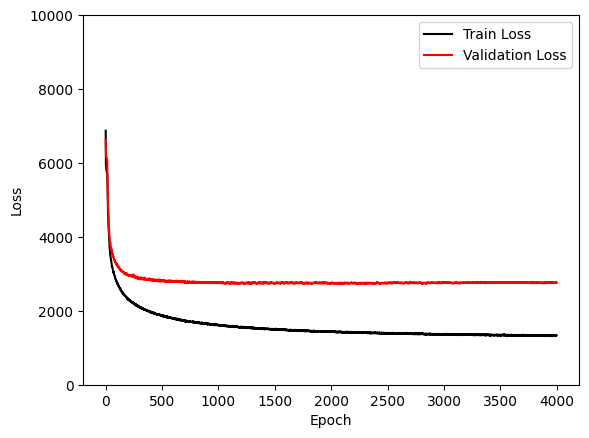

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
log_plot = pd.read_csv(db_path + model_path + "/logs/" + model_name + "/version_2/metrics.csv")
log_plot = log_plot.loc[:, ['epoch', 'val_loss', 'train_loss_epoch']]

# 결측값 제거 및 인덱스 재설정
val_loss_log = log_plot['val_loss'].dropna().reset_index(drop=True)
train_loss_log = log_plot['train_loss_epoch'].dropna().reset_index(drop=True)

# 두 데이터를 합침
log_plot_sum = pd.concat([train_loss_log, val_loss_log], axis=1)

# x 값 재설정 (길이를 로그 데이터와 맞춤)
x = range(len(log_plot_sum))

# Series 객체를 numpy 배열로 변환
train_loss = log_plot_sum['train_loss_epoch'].values
val_loss = log_plot_sum['val_loss'].values

# 그래프 그리기
plt.plot(x, train_loss, c='k', label='Train Loss')
plt.plot(x, val_loss, c='r', label='Validation Loss')
plt.ylim(0, 10000)

# 레이블 추가
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# 그래프 보여주기
plt.show()

Selected (index, MAE):
(1759, 190.33075)
(3271, 190.35959)
(651, 190.36272)
(6204, 380.1825)
(3840, 380.20386)
(5411, 380.36716)
(2766, 792.73975)
(808, 792.814)
(4611, 792.92065)


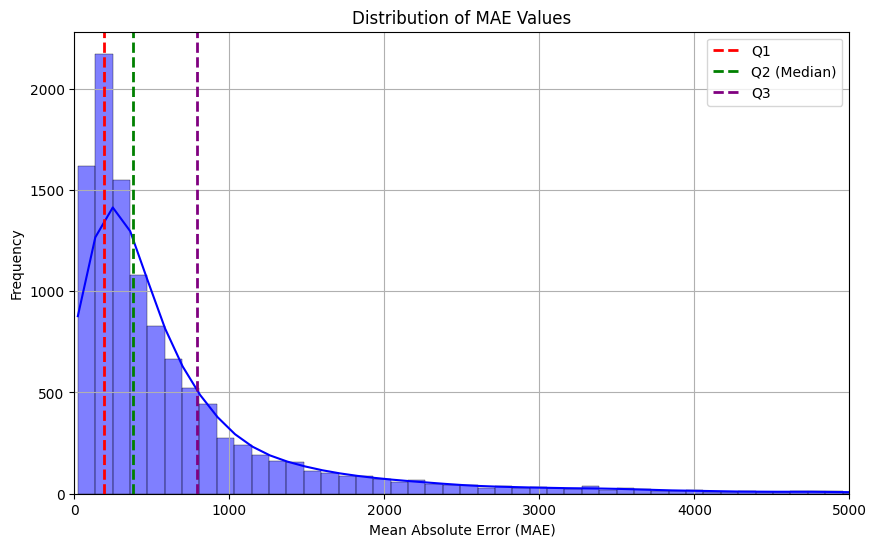

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. numpy 배열 변환
# =========================
train_mae_array = np.array(train_mae)

# =========================
# 2. 정렬 (index 유지)
# =========================
train_sorted = sorted(list(enumerate(train_mae_array)), key=lambda x: x[1])

# =========================
# 3. 분위수 위치 계산
# =========================
n = len(train_sorted)

q1_idx = int(0.25 * (n - 1))
q2_idx = int(0.50 * (n - 1))
q3_idx = int(0.75 * (n - 1))

# =========================
# 4. 앞뒤 포인트 포함 인덱스
# =========================
selected_positions = [
    q1_idx - 1, q1_idx, q1_idx + 1,
    q2_idx - 1, q2_idx, q2_idx + 1,
    q3_idx - 1, q3_idx, q3_idx + 1
]

# 범위 안전 처리
selected_positions = [max(0, min(n-1, idx)) for idx in selected_positions]

# 중복 제거
selected_positions = sorted(set(selected_positions))

train_selected_values = [train_sorted[i] for i in selected_positions]

print("Selected (index, MAE):")
for val in train_selected_values:
    print(val)

# =========================
# 5. Distribution Plot
# =========================
plt.figure(figsize=(10, 6))

sns.histplot(train_mae_array, kde=True, bins=200, color="blue")
plt.xlim(0, 5000)

plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Frequency")
plt.title("Distribution of MAE Values")
plt.grid(True)

# 분위수 수직선
q1_val = train_sorted[q1_idx][1]
q2_val = train_sorted[q2_idx][1]
q3_val = train_sorted[q3_idx][1]

plt.axvline(q1_val, color='red', linestyle='--', linewidth=2, label="Q1")
plt.axvline(q2_val, color='green', linestyle='--', linewidth=2, label="Q2 (Median)")
plt.axvline(q3_val, color='purple', linestyle='--', linewidth=2, label="Q3")

plt.legend()
plt.show()

In [28]:
from scipy.signal import find_peaks

def find_max_peak(data):
    peaks_list = []
    view_df = pd.DataFrame(data)

    for i in range(len(view_df)):
        X = view_df.columns[2:]
        Y = view_df.iloc[i, 2:]
        max_value = np.max(Y)
        relative_height = 0.1
        absolute_height = max_value * relative_height

        peaks, properties = find_peaks(Y, height=absolute_height, distance=7)

        if len(peaks) > 0:
            if peaks[0] < 5:
                peaks = peaks[1:]

        if len(peaks) > 0:
            if peaks[-1] > len(Y) - 5:
                peaks = peaks[:-1]

        if len(peaks) == 0:
            peaks_list.append('NaN')
        else:
            peaks_list.append(peaks[-1])

    return peaks_list


train_pred_peaks = find_max_peak(train_pred)
train_y_peaks = find_max_peak(train_y)

val_pred_peaks = find_max_peak(val_pred)
val_y_peaks = find_max_peak(val_y)

In [29]:
train_x_skew = []
train_y_skew = []

for i in range(len(val_pred_peaks)):
    if val_pred_peaks[i] != 'NaN' and val_y_peaks[i] != 'NaN':
        train_x_skew.append(np.square(2*(val_pred_peaks[i] - val_y_peaks[i])))
        train_y_skew.append(np.square(np.log10(val_y[i][val_y_peaks[i]])
                                    - np.log10(val_pred[i][val_pred_peaks[i]])))
    else:
        pass

print("train_x_skew: ", round(np.sqrt(np.mean(train_x_skew)), 3))
print("train_y_skew: ", round(np.sqrt(np.mean(train_y_skew)), 3))

train_x_skew:  33.523
train_y_skew:  0.239


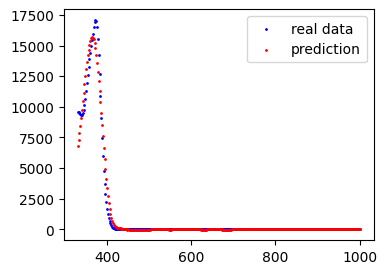

CCCCC(CC)Cn1c2ccc(C(=O)C(CC)=NOC(=O)c3ccccc3)cc2c2c3oc(=O)cc(C)c3ccc21
CC#N
190.33075


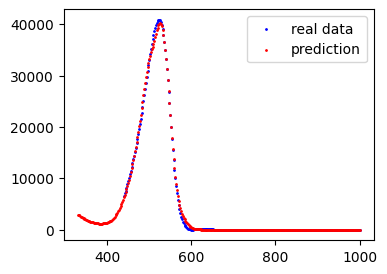

CCCCNc1sc(N=Nc2nc(C(=O)OCC)cs2)nc1C(=O)OCC
C1CCOC1
190.35959


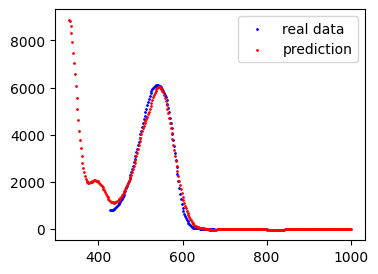

CC(C)(C)c1ccc(C2=C(c3ccccc3)C(c3ccccc3)=NC2=C(c2ccc(C(C)(C)C)cc2)c2[nH]c(-c3ccccc3)c(-c3ccccc3)c2-c2ccc(C(C)(C)C)cc2)cc1
ClCCl
190.36272


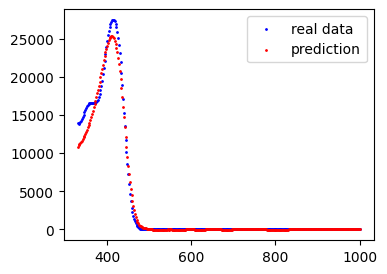

COc1ccc(N(c2ccc(OC)cc2)c2ccc3c(c2)C2(c4cc(N(c5ccc(OC)cc5)c5ccc(OC)cc5)ccc4C=C3)c3ccccc3-c3ccccc32)cc1
ClCCl
380.1825


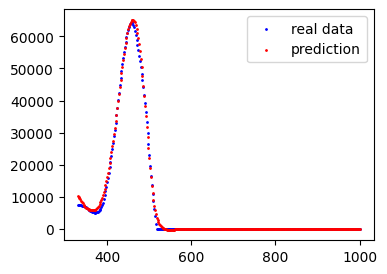

CCN(CC)c1ccc2cc(-c3ccc(-c4nc5c6ccccc6c6ccccc6c5[nH]4)s3)c(=O)oc2c1
C1CCOC1
380.20386


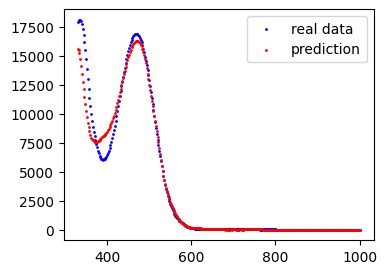

COC(=O)C=Cc1sc(-c2ccc(N(C)C)s2)cc1-c1nccs1
CC#N
380.36716


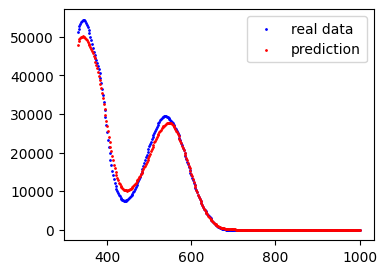

CCCCCCOc1ccc(-c2ccc(N(c3ccc(-c4ccc(OCCCCCC)cc4OCCCCCC)cc3)c3ccc4c5sc(-c6ccc(-c7ccc(C=C(C#N)C(=O)O)cc7)c7nsnc67)cc5n(CCCCCC)c4c3)cc2)c(OCCCCCC)c1
C1CCOC1
792.73975


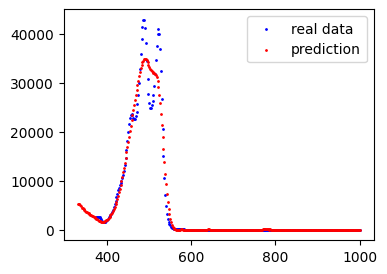

CC(C)(C)c1ccc2c(c1)sc1[n+]2[B-](F)(F)n2c(c3cccc4cccc2c43)=C1C#N
ClCCl
792.814


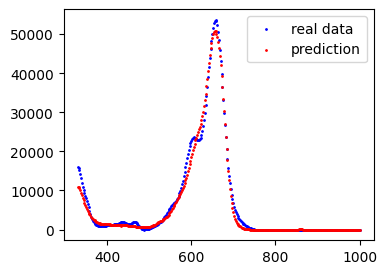

CC[Si](C#Cc1c2c(Cl)cccc2c2c3ccc(Cl)c4c(C#C[Si](CC)(CC)CC)c5c(Cl)cccc5c(c5ccc(Cl)c1c52)c43)(CC)CC
ClC(Cl)Cl
792.92065


In [30]:
x = np.linspace(330, 1000, 336)
import random
checklist = [v[0] for v in train_selected_values]

for i in checklist:
    plt.figure(figsize=(4, 3))
    plt.scatter(x, train_y[i], c='b', s=1, label='real data')
    plt.scatter(x, train_pred[i], c='r', s=1, label='prediction')

    plt.legend()
    plt.show()
    
    train_path = 'data/Train_abs_spectrum_sum_12496_251216.csv'
    view_train_df = pd.read_csv(train_path)
    
    print(view_train_df.loc[i, 'Chromophore_smiles'])
    print(view_train_df.loc[i, 'Solvent_smiles'])
    print(train_mae[i])
    
    Chem.MolFromSmiles(view_train_df.loc[i, 'Chromophore_smiles'])

Selected (index, MAE):
(573, 691.9749)
(415, 692.0802)
(500, 693.6525)
(717, 1705.0524)
(492, 1707.9412)
(1066, 1709.288)
(507, 3718.84)
(176, 3719.243)
(1026, 3719.843)


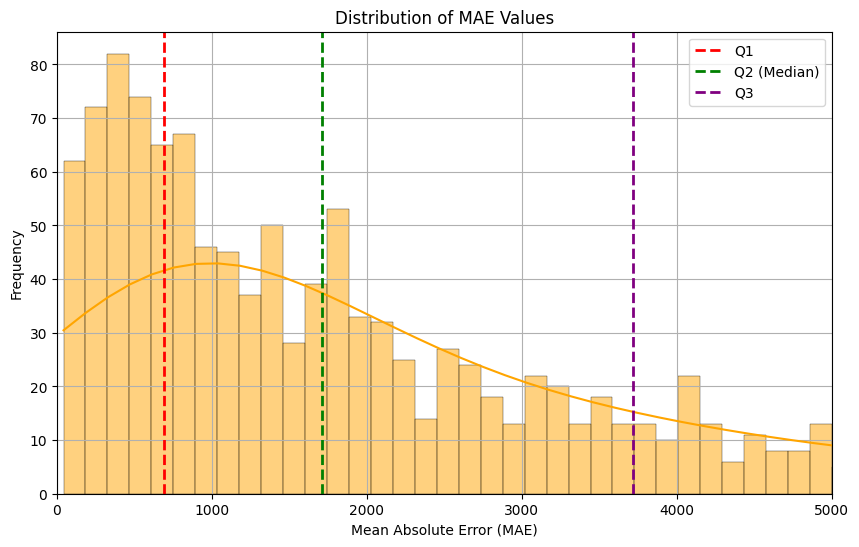

In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. numpy 배열 변환
# =========================
val_mae_array = np.array(val_mae)

# =========================
# 2. 정렬 (index 유지)
# =========================
val_sorted = sorted(list(enumerate(val_mae_array)), key=lambda x: x[1])

# =========================
# 3. 분위수 위치 계산
# =========================
n = len(val_sorted)

q1_idx = int(0.25 * (n - 1))
q2_idx = int(0.50 * (n - 1))
q3_idx = int(0.75 * (n - 1))

# =========================
# 4. 앞뒤 포인트 포함 인덱스
# =========================
selected_positions = [
    q1_idx - 1, q1_idx, q1_idx + 1,
    q2_idx - 1, q2_idx, q2_idx + 1,
    q3_idx - 1, q3_idx, q3_idx + 1
]

# 범위 안전 처리
selected_positions = [max(0, min(n-1, idx)) for idx in selected_positions]

# 중복 제거
selected_positions = sorted(set(selected_positions))

val_selected_values = [val_sorted[i] for i in selected_positions]

print("Selected (index, MAE):")
for val in val_selected_values:
    print(val)

# =========================
# 5. Distribution Plot
# =========================
plt.figure(figsize=(10, 6))

sns.histplot(val_mae_array, kde=True, bins=200, color="orange")
plt.xlim(0, 5000)

plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Frequency")
plt.title("Distribution of MAE Values")
plt.grid(True)

# 분위수 수직선
q1_val = val_sorted[q1_idx][1]
q2_val = val_sorted[q2_idx][1]
q3_val = val_sorted[q3_idx][1]

plt.axvline(q1_val, color='red', linestyle='--', linewidth=2, label="Q1")
plt.axvline(q2_val, color='green', linestyle='--', linewidth=2, label="Q2 (Median)")
plt.axvline(q3_val, color='purple', linestyle='--', linewidth=2, label="Q3")

plt.legend()
plt.show()

In [32]:
from scipy.signal import find_peaks

def find_max_peak(data):
    peaks_list = []
    view_df = pd.DataFrame(data)

    for i in range(len(view_df)):
        X = view_df.columns[2:]
        Y = view_df.iloc[i, 2:]
        max_value = np.max(Y)
        relative_height = 0.1
        absolute_height = max_value * relative_height

        peaks, properties = find_peaks(Y, height=absolute_height, distance=7)

        if len(peaks) > 0:
            if peaks[0] < 5:
                peaks = peaks[1:]

        if len(peaks) > 0:
            if peaks[-1] > len(Y) - 5:
                peaks = peaks[:-1]

        if len(peaks) == 0:
            peaks_list.append('NaN')
        else:
            peaks_list.append(peaks[-1])

    return peaks_list


train_pred_peaks = find_max_peak(train_pred)
train_y_peaks = find_max_peak(train_y)

val_pred_peaks = find_max_peak(val_pred)
val_y_peaks = find_max_peak(val_y)

In [33]:
val_x_skew = []
val_y_skew = []

for i in range(len(val_pred_peaks)):
    if val_pred_peaks[i] != 'NaN' and val_y_peaks[i] != 'NaN':
        val_x_skew.append(np.square(2*(val_pred_peaks[i] - val_y_peaks[i])))
        val_y_skew.append(np.square(np.log10(val_y[i][val_y_peaks[i]])
                                    - np.log10(val_pred[i][val_pred_peaks[i]])))
    else:
        pass

print("val_x_skew: ", round(np.sqrt(np.mean(val_x_skew)), 3))
print("val_y_skew: ", round(np.sqrt(np.mean(val_y_skew)), 3))

val_x_skew:  33.523
val_y_skew:  0.239


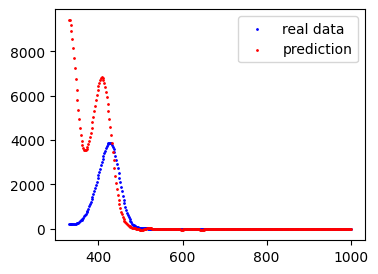

CCOC(=O)c1nc2ncc(C#N)c(-c3ccc(N(C)C)cc3)n2n1
C1CCOC1
691.9749


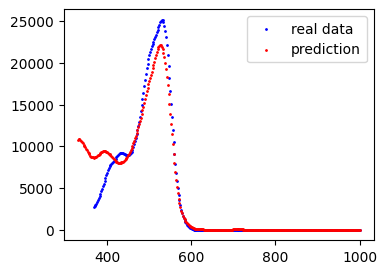

CCCCOC(=O)c1cc(Oc2ccc(OC)cc2)c2c3c(Cl)cc4c5c(cc(Cl)c(c6c(Oc7ccc(OC)cc7)cc(C(=O)OCCCC)c1c26)c53)C(=O)N(c1c(C(C)C)cccc1C(C)C)C4=O
Cc1ccccc1
692.0802


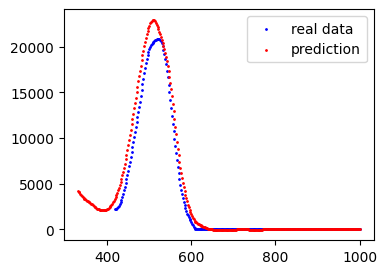

CCN(CC)c1ccc2cc(-c3ccc(C=C(C#N)C#N)s3)c(=O)oc2c1
CO
693.6525


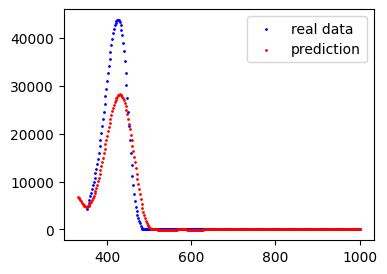

COc1cc2c(cc1C=C(C#N)C#N)c1ccccc1n2C
CN(C)C=O
1705.0524


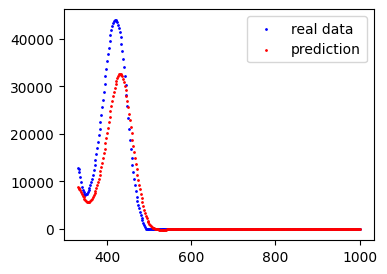

CCN(CC)c1ccc2cc(-c3ccc(C(=O)C=Cc4ccccc4)cc3)c(=O)oc2c1
CC#N
1707.9412


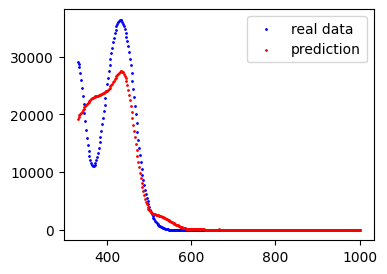

O=P1(c2ccccc2)c2cc(-c3ccc(N4c5ccccc5Sc5ccccc54)cc3)sc2-c2sc(-c3ccc(N4c5ccccc5Sc5ccccc54)cc3)cc21
ClC(Cl)Cl
1709.288


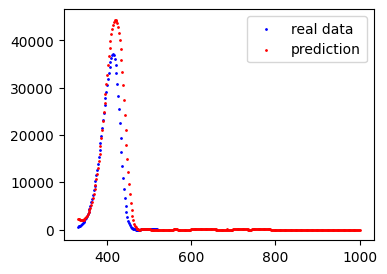

CCN(CC)c1ccc2cc(C(=O)NCc3ccccc3)c(=O)oc2c1
CC#N
3718.84


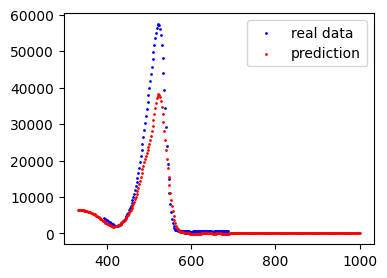

CC1=CC(C)=[N+]2C1=Cc1ccc(-c3ccc(C#N)cc3)n1[B-]2(F)F
ClCCl
3719.243


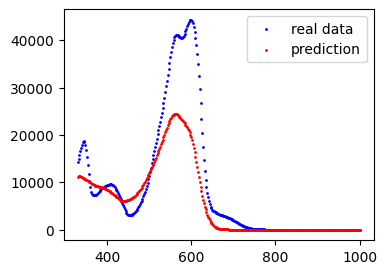

O=C(O)CN1C(=O)C2=C(c3ccc(-c4cccs4)s3)N(CC(=O)O)C(=O)C2=C1c1ccc(-c2cccs2)s1
CO
3719.843


In [34]:
x = np.linspace(330, 1000, 336)
import random
checklist = [v[0] for v in val_selected_values]

for i in checklist:
    plt.figure(figsize=(4, 3))
    plt.scatter(x, val_y[i], c='b', s=1, label='real data')
    plt.scatter(x, val_pred[i], c='r', s=1, label='prediction')

    plt.legend()
    plt.show()
    
    val_path = 'data/Test_abs_spectrum_sum_12496_251216.csv'
    view_val_df = pd.read_csv(val_path)
    
    print(view_val_df.loc[i, 'Chromophore_smiles'])
    print(view_val_df.loc[i, 'Solvent_smiles'])
    print(val_mae[i])
    
    Chem.MolFromSmiles(view_val_df.loc[i, 'Chromophore_smiles'])